Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 8, 64)     │        448 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 4, 64)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4, 64)     │        256 │ max_pooling1d[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,216 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 45,313 (177.00 KB)

 Trainable params: 45,185 (176.50 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1051 - mae: 0.2520 - val_loss: 0.0163 - val_mae: 0.0997
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127 - mae: 0.0864 - val_loss: 0.0154 - val_mae: 0.0922
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0087 - mae: 0.0708 - val_loss: 0.0156 - val_mae: 0.0922
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0080 - mae: 0.0687 - val_loss: 0.0141 - val_mae: 0.0885
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059 - mae: 0.0611 - val_loss: 0.0152 - val_mae: 0.0912
Epoch 6/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0064 - mae: 0.0605 - val_loss: 0.0119 - val_mae: 0.0804
Epoch 7/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - mae: 0.0589 - val_loss: 0.0112 - val_mae: 0.0784
Epoch 8/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - mae: 0.0544 - val_loss: 0.0107 - val_mae: 0.0760
Epoch 9/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.00

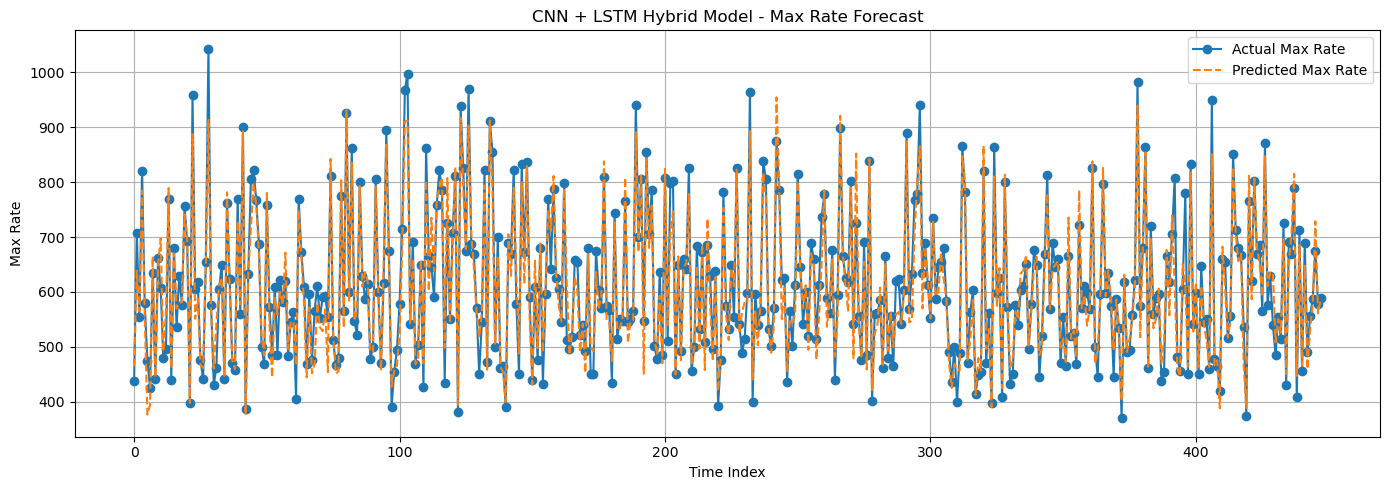

In [4]:
# === Hybrid CNN-LSTM Model for Forecasting Cocoon Market Prices ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# === Load & Preprocess Dataset ===
df = pd.read_csv('/Users/user/Downloads/final_cleaned_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
date_col = df['Date']
df.drop(columns=['Date'], inplace=True)

# === Feature Selection ===
target_col = 'Max Rate'
time_series_features = ['Quantity', 'Max Rate']
static_features = [col for col in df.columns if col not in [target_col] + time_series_features]

# === Sequence Preparation ===
def create_sequences(data, static_data, target, time_steps=10):
    X_seq, X_static, y = [], [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i+time_steps])
        X_static.append(static_data[i+time_steps])
        y.append(target[i+time_steps])
    return np.array(X_seq), np.array(X_static), np.array(y)

scaler_seq = MinMaxScaler()
scaler_static = MinMaxScaler()
scaler_y = MinMaxScaler()
df_scaled_seq = scaler_seq.fit_transform(df[time_series_features])
df_scaled_static = scaler_static.fit_transform(df[static_features])
target_scaled = scaler_y.fit_transform(df[[target_col]])

X_seq, X_static, y = create_sequences(df_scaled_seq, df_scaled_static, target_scaled, time_steps=10)

X_seq_train, X_seq_test, X_static_train, X_static_test, y_train, y_test = train_test_split(
    X_seq, X_static, y, test_size=0.2, random_state=42)

# === Model Architecture ===
def build_model(seq_shape, static_shape):
    seq_input = Input(shape=seq_shape, name='seq_input')
    x1 = Conv1D(filters=64, kernel_size=3, activation='relu')(seq_input)
    x1 = MaxPooling1D(pool_size=2)(x1)
    x1 = BatchNormalization()(x1)
    x1 = LSTM(64, return_sequences=False)(x1)
    x1 = Dropout(0.3)(x1)

    static_input = Input(shape=(static_shape,), name='static_input')
    x2 = Dense(64, activation='relu')(static_input)
    x2 = Dropout(0.3)(x2)

    x = Concatenate()([x1, x2])
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(X_seq_train.shape[1:], X_static_train.shape[1])
model.summary()

# === Model Training ===
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(
    [X_seq_train, X_static_train], y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# === Model Evaluation ===
y_pred = model.predict([X_seq_test, X_static_test])
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)
accuracy = 100 - np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print(f"\n📊 Test Metrics:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}, Accuracy: {accuracy:.2f}%")

# === Plotting Actual vs Predicted ===
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv, label='Actual Max Rate', marker='o')
plt.plot(y_pred_inv, label='Predicted Max Rate', linestyle='--')
plt.title("CNN + LSTM Hybrid Model - Max Rate Forecast")
plt.xlabel("Time Index")
plt.ylabel("Max Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


2025-04-15 23:22:08.646674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 8, 128)    │        896 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 4, 128)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 4, 128)    │     98,816 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 128)       │        132 │ bidirectional[0]… │
│ (Attention)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,216 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     12,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 115,525 (451.27 KB)

 Trainable params: 115,525 (451.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0797 - mae: 0.2189 - val_loss: 0.0083 - val_mae: 0.0707 - learning_rate: 0.0010
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0113 - mae: 0.0826 - val_loss: 0.0023 - val_mae: 0.0355 - learning_rate: 0.0010
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0068 - mae: 0.0630 - val_loss: 0.0024 - val_mae: 0.0375 - learning_rate: 0.0010
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061 - mae: 0.0576 - val_loss: 0.0020 - val_mae: 0.0334 - learning_rate: 0.0010
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056 - mae: 0.0552 - val_loss: 0.0039 - val_mae: 0.0510 - learning_rate: 0.0010
Epoch 6/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - mae: 0.0510 - val_loss: 0.0027 - val_mae: 0.0406 - learning_rate: 0.0010
Epoch 7/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0050 - mae: 0.0497 - val_loss: 0.0027 - val_mae: 0.0418 - learning_rate: 0.0010
Epoch 8/150


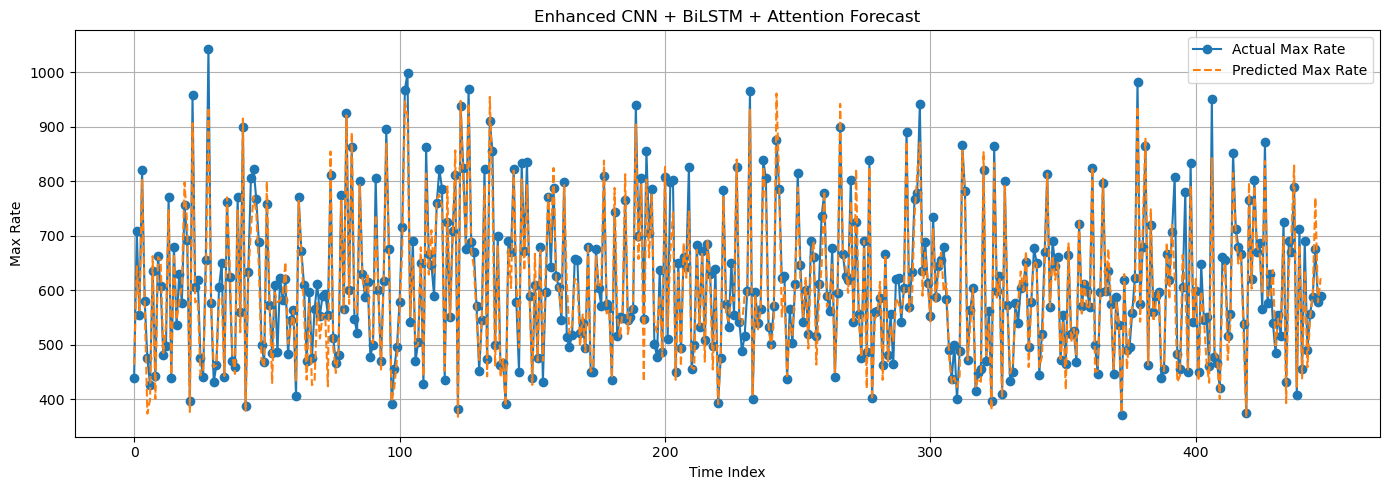

In [4]:
# === Best Version: Hybrid CNN + Bidirectional LSTM with Attention ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate, 
                                     Conv1D, MaxPooling1D, Bidirectional, Layer)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

# === Attention Layer ===
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

# === Load & Preprocess Data ===
df = pd.read_csv('/Users/user/Downloads/final_cleaned_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Extract date parts
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Save for plotting
date_col = df['Date']
df.drop(columns=['Date'], inplace=True)

# Define Features
target_col = 'Max Rate'
time_series_features = ['Quantity', 'Max Rate']
static_features = [col for col in df.columns if col not in [target_col] + time_series_features]

# Normalize
tscaler = MinMaxScaler()
sscaler = MinMaxScaler()
yscaler = MinMaxScaler()

df_seq_scaled = tscaler.fit_transform(df[time_series_features])
df_static_scaled = sscaler.fit_transform(df[static_features])
y_scaled = yscaler.fit_transform(df[[target_col]])

# Create Sequences
def create_sequences(data, static, target, time_steps=10):
    X_seq, X_static, y = [], [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i+time_steps])
        X_static.append(static[i+time_steps])
        y.append(target[i+time_steps])
    return np.array(X_seq), np.array(X_static), np.array(y)

X_seq, X_static, y = create_sequences(df_seq_scaled, df_static_scaled, y_scaled)

# Split
X_seq_train, X_seq_test, X_static_train, X_static_test, y_train, y_test = train_test_split(
    X_seq, X_static, y, test_size=0.2, random_state=42
)

# === Build Enhanced Model ===
def build_model(seq_shape, static_shape):
    seq_input = Input(shape=seq_shape, name='seq_input')
    x = Conv1D(128, kernel_size=3, activation='relu')(seq_input)
    x = MaxPooling1D(pool_size=2)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Attention()(x)
    x = Dropout(0.3)(x)

    static_input = Input(shape=(static_shape,), name='static_input')
    y = Dense(64, activation='relu')(static_input)
    y = Dropout(0.3)(y)

    combined = Concatenate()([x, y])
    z = Dense(64, activation='relu')(combined)
    z = Dense(32, activation='relu')(z)
    output = Dense(1)(z)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(X_seq_train.shape[1:], X_static_train.shape[1])
model.summary()

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# === Train ===
history = model.fit(
    [X_seq_train, X_static_train], y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# === Evaluate ===
y_pred = model.predict([X_seq_test, X_static_test])
y_test_inv = yscaler.inverse_transform(y_test)
y_pred_inv = yscaler.inverse_transform(y_pred)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)
accuracy = 100 - (mae / np.mean(y_test_inv) * 100)

print(f"\n📊 Test Metrics:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}, Accuracy: {accuracy:.2f}%")

# === Plot ===
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv, label='Actual Max Rate', marker='o')
plt.plot(y_pred_inv, label='Predicted Max Rate', linestyle='--')
plt.title("Enhanced CNN + BiLSTM + Attention Forecast")
plt.xlabel("Time Index")
plt.ylabel("Max Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 8, 128)    │        896 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 4, 128)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 4, 128)    │     98,816 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 128)       │        132 │ bidirectional[0]… │
│ (Attention)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,216 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     12,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 115,525 (451.27 KB)

 Trainable params: 115,525 (451.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0600 - mae: 0.1906 - val_loss: 0.0045 - val_mae: 0.0506 - learning_rate: 0.0010
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0076 - mae: 0.0660 - val_loss: 0.0029 - val_mae: 0.0411 - learning_rate: 0.0010
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0056 - mae: 0.0533 - val_loss: 0.0025 - val_mae: 0.0398 - learning_rate: 0.0010
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - mae: 0.0511 - val_loss: 0.0033 - val_mae: 0.0470 - learning_rate: 0.0010
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0050 - mae: 0.0509 - val_loss: 0.0017 - val_mae: 0.0307 - learning_rate: 0.0010
Epoch 6/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - mae: 0.0465 - val_loss: 0.0037 - val_mae: 0.0512 - learning_rate: 0.0010
Epoch 7/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - mae: 0.0466 - val_loss: 0.0019 - val_mae: 0.0333 - learning_rate: 0.0010
Epoch 8/150


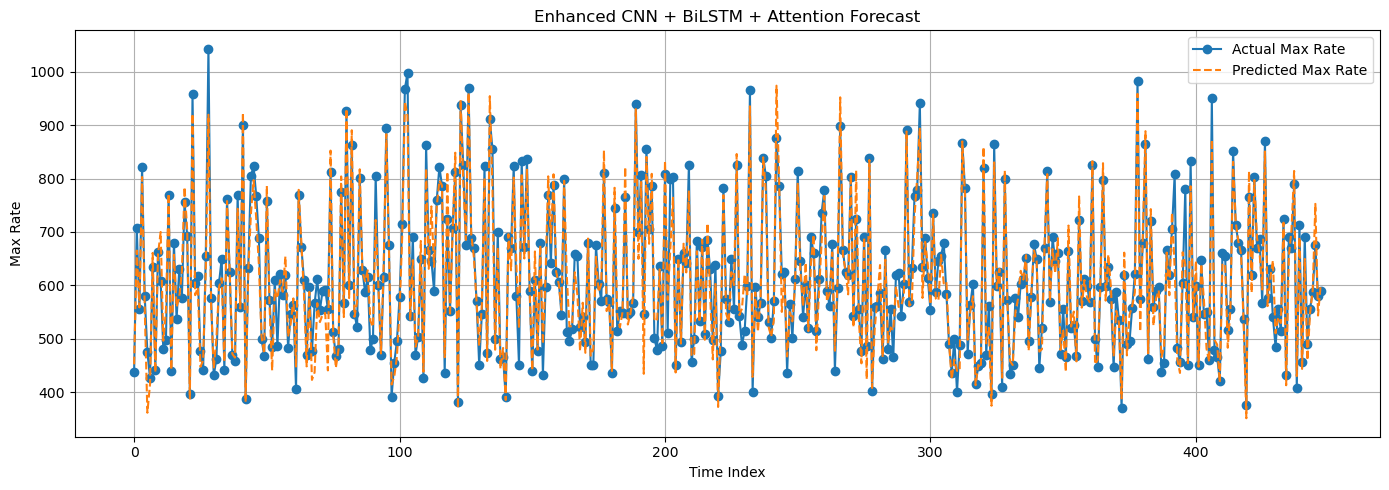

In [4]:
# === Best Version: Hybrid CNN + Bidirectional LSTM with Attention ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate, 
                                     Conv1D, MaxPooling1D, Bidirectional, Layer)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

# === Attention Layer ===
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

# === Load & Preprocess Data ===
df = pd.read_csv('/Users/user/Downloads/final_cleaned_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Extract date parts
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Save for plotting
date_col = df['Date']
df.drop(columns=['Date'], inplace=True)

# Define Features
target_col = 'Max Rate'
time_series_features = ['Quantity', 'Max Rate']
static_features = [col for col in df.columns if col not in [target_col] + time_series_features]

# Normalize
tscaler = MinMaxScaler()
sscaler = MinMaxScaler()
yscaler = MinMaxScaler()

df_seq_scaled = tscaler.fit_transform(df[time_series_features])
df_static_scaled = sscaler.fit_transform(df[static_features])
y_scaled = yscaler.fit_transform(df[[target_col]])

# Create Sequences
def create_sequences(data, static, target, time_steps=10):
    X_seq, X_static, y = [], [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i+time_steps])
        X_static.append(static[i+time_steps])
        y.append(target[i+time_steps])
    return np.array(X_seq), np.array(X_static), np.array(y)

X_seq, X_static, y = create_sequences(df_seq_scaled, df_static_scaled, y_scaled)

# Split
X_seq_train, X_seq_test, X_static_train, X_static_test, y_train, y_test = train_test_split(
    X_seq, X_static, y, test_size=0.2, random_state=42
)

# === Build Enhanced Model ===
def build_model(seq_shape, static_shape):
    seq_input = Input(shape=seq_shape, name='seq_input')
    x = Conv1D(128, kernel_size=3, activation='relu')(seq_input)
    x = MaxPooling1D(pool_size=2)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Attention()(x)
    x = Dropout(0.3)(x)

    static_input = Input(shape=(static_shape,), name='static_input')
    y = Dense(64, activation='relu')(static_input)
    y = Dropout(0.3)(y)

    combined = Concatenate()([x, y])
    z = Dense(64, activation='relu')(combined)
    z = Dense(32, activation='relu')(z)
    output = Dense(1)(z)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(X_seq_train.shape[1:], X_static_train.shape[1])
model.summary()

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# === Train ===
history = model.fit(
    [X_seq_train, X_static_train], y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# === Evaluate ===
y_pred = model.predict([X_seq_test, X_static_test])
y_test_inv = yscaler.inverse_transform(y_test)
y_pred_inv = yscaler.inverse_transform(y_pred)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)
accuracy = 100 - (mae / np.mean(y_test_inv) * 100)

print(f"\n📊 Test Metrics:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}, Accuracy: {accuracy:.2f}%")

# === Plot ===
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv, label='Actual Max Rate', marker='o')
plt.plot(y_pred_inv, label='Predicted Max Rate', linestyle='--')
plt.title("Enhanced CNN + BiLSTM + Attention Forecast")
plt.xlabel("Time Index")
plt.ylabel("Max Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


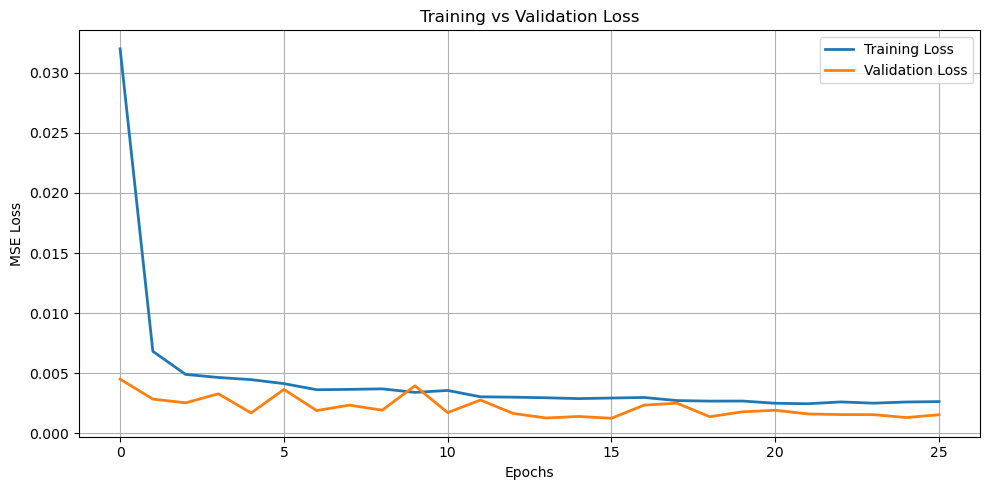

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


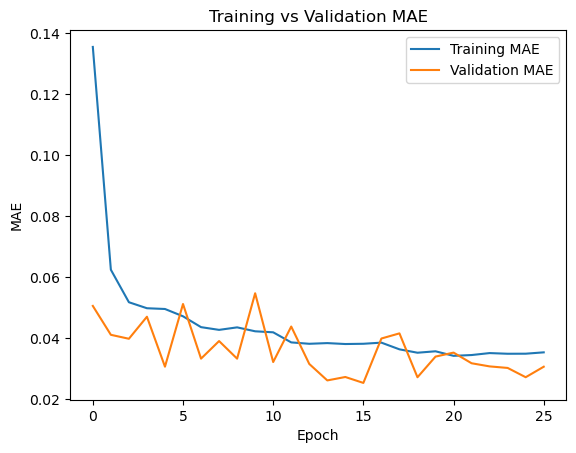

In [9]:
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()


In [16]:
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")


Final Training Loss: 0.0026
Final Validation Loss: 0.0015


In [25]:
display(static_features)
print("..............")
display(time_series_features)

['Last Year Quantity',
 'Avg Last Year',
 'Average Temperature (°C)',
 'Average Dew Point (°C)',
 'Average Humidity (%)',
 'Average Wind Speed (km/h)',
 'Average Pressure (hPa)',
 'Year',
 'Month',
 'Day',
 'Variety_Mishrathali',
 'Disease_Flacherie',
 'Disease_Grasserie',
 'Disease_Muscardine',
 'Disease_Nematodes and Parasitic Worms',
 'Disease_Pebrine',
 'Disease_Uzi Fly',
 'DayOfWeek']

..............


['Quantity', 'Max Rate']

In [17]:
# === Hybrid CNN-LSTM Model with K-Fold Cross-Validation for Cocoon Market Price Forecasting ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# === Load & Preprocess Dataset ===
df = pd.read_csv('/Users/user/Downloads/final_cleaned_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df.drop(columns=['Date'], inplace=True)

# === Feature Setup ===
target_col = 'Max Rate'
time_series_features = ['Quantity', 'Max Rate']
static_features = [col for col in df.columns if col not in [target_col] + time_series_features]

# === Scaling ===
scaler_seq = MinMaxScaler()
scaler_static = MinMaxScaler()
scaler_y = MinMaxScaler()

df_scaled_seq = scaler_seq.fit_transform(df[time_series_features])
df_scaled_static = scaler_static.fit_transform(df[static_features])
target_scaled = scaler_y.fit_transform(df[[target_col]])

# === Sequence Preparation ===
def create_sequences(data, static_data, target, time_steps=10):
    X_seq, X_static, y = [], [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i+time_steps])
        X_static.append(static_data[i+time_steps])
        y.append(target[i+time_steps])
    return np.array(X_seq), np.array(X_static), np.array(y)

time_steps = 10
X_seq, X_static, y = create_sequences(df_scaled_seq, df_scaled_static, target_scaled, time_steps)

# === Model Architecture ===
def build_model(seq_shape, static_shape):
    seq_input = Input(shape=seq_shape, name='seq_input')
    x1 = Conv1D(filters=64, kernel_size=3, activation='relu')(seq_input)
    x1 = MaxPooling1D(pool_size=2)(x1)
    x1 = BatchNormalization()(x1)
    x1 = LSTM(64, return_sequences=False)(x1)
    x1 = Dropout(0.3)(x1)

    static_input = Input(shape=(static_shape,), name='static_input')
    x2 = Dense(64, activation='relu')(static_input)
    x2 = Dropout(0.3)(x2)

    x = Concatenate()([x1, x2])
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# === K-Fold Cross-Validation ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores, rmse_scores, r2_scores, accuracy_scores = [], [], [], []

fold = 1
for train_idx, test_idx in kf.split(X_seq):
    print(f"\n🔁 Fold {fold}")

    X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
    X_static_train, X_static_test = X_static[train_idx], X_static[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = build_model(X_seq_train.shape[1:], X_static_train.shape[1])

    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(
        [X_seq_train, X_static_train], y_train,
        validation_split=0.2,
        epochs=150,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = model.predict([X_seq_test, X_static_test], verbose=0)
    y_test_inv = scaler_y.inverse_transform(y_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred)

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    r2 = r2_score(y_test_inv, y_pred_inv)
    accuracy = 100 - np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    accuracy_scores.append(accuracy)

    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}, Accuracy: {accuracy:.2f}%")
    fold += 1

# === Final Results ===
print("\n📈 Average Metrics Across Folds:")
print(f"Mean MAE: {np.mean(mae_scores):.2f}")
print(f"Mean RMSE: {np.mean(rmse_scores):.2f}")
print(f"Mean R²: {np.mean(r2_scores):.2f}")
print(f"Mean Accuracy: {np.mean(accuracy_scores):.2f}%")



🔁 Fold 1
MAE: 127.07, RMSE: 170.55, R²: -0.57, Accuracy: 81.60%

🔁 Fold 2
MAE: 56.69, RMSE: 75.19, R²: 0.69, Accuracy: 91.66%

🔁 Fold 3
MAE: 44.69, RMSE: 55.57, R²: 0.83, Accuracy: 92.95%

🔁 Fold 4
MAE: 46.04, RMSE: 71.45, R²: 0.76, Accuracy: 89.18%

🔁 Fold 5
MAE: 46.94, RMSE: 59.95, R²: 0.79, Accuracy: 92.72%

📈 Average Metrics Across Folds:
Mean MAE: 64.29
Mean RMSE: 86.54
Mean R²: 0.50
Mean Accuracy: 89.63%


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 8, 128)    │        896 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 4, 128)    │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 4, 128)    │     98,816 │ max_pooling1d_7[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lightweight_attent… │ (None, 128)       │        132 │ bidirectional_2[… │
│ (LightweightAttent… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 64)        │      1,216 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 128)       │          0 │ lightweight_atte… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ dense_28[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 192)       │          0 │ dropout_14[0][0], │
│ (Concatenate)       │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 64)        │     12,352 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 32)        │      2,080 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 1)         │         33 │ dense_30[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 115,525 (451.27 KB)

 Trainable params: 115,525 (451.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1034 - mae: 0.2487 - val_loss: 0.0145 - val_mae: 0.0947 - learning_rate: 0.0010
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0123 - mae: 0.0866 - val_loss: 0.0065 - val_mae: 0.0659 - learning_rate: 0.0010
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0062 - mae: 0.0609 - val_loss: 0.0023 - val_mae: 0.0358 - learning_rate: 0.0010
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 - mae: 0.0563 - val_loss: 0.0025 - val_mae: 0.0378 - learning_rate: 0.0010
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0051 - mae: 0.0508 - val_loss: 0.0034 - val_mae: 0.0477 - learning_rate: 0.0010
Epoch 6/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - mae: 0.0485 - val_loss: 0.0019 - val_mae: 0.0308 - learning_rate: 0.0010
Epoch 7/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - mae: 0.0492 - val_loss: 0.0018 - val_mae: 0.0308 - learning_rate: 0.0010
Epoch 8/150


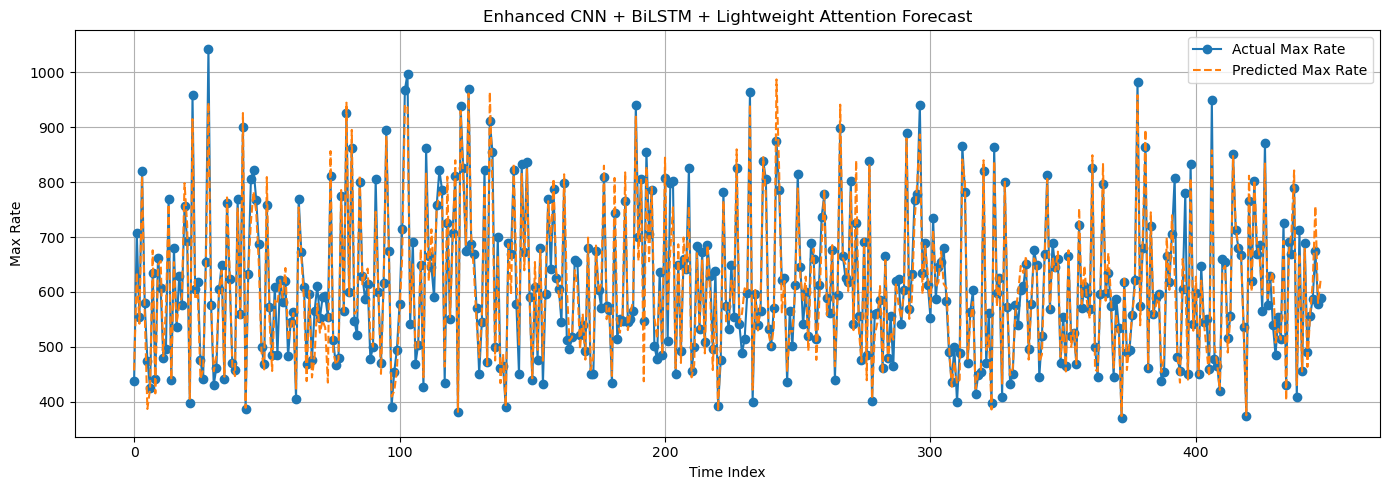

In [19]:
# === Full Code with Lightweight Attention ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate, 
                                     Conv1D, MaxPooling1D, Bidirectional, Layer)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

# === Lightweight Attention Layer ===
class LightweightAttention(Layer):
    def __init__(self, **kwargs):
        super(LightweightAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(LightweightAttention, self).build(input_shape)

    def call(self, x):
        # Attention mechanism using dot product
        e = K.dot(x, self.W) + self.b
        a = K.softmax(e, axis=1)
        output = x * a  # Apply attention weights
        return K.sum(output, axis=1)

# === Load & Preprocess Data ===
df = pd.read_csv('/Users/user/Downloads/final_cleaned_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Extract date parts
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Save for plotting
date_col = df['Date']
df.drop(columns=['Date'], inplace=True)

# Define Features
target_col = 'Max Rate'
time_series_features = ['Quantity', 'Max Rate']
static_features = [col for col in df.columns if col not in [target_col] + time_series_features]

# Normalize
tscaler = MinMaxScaler()
sscaler = MinMaxScaler()
yscaler = MinMaxScaler()

df_seq_scaled = tscaler.fit_transform(df[time_series_features])
df_static_scaled = sscaler.fit_transform(df[static_features])
y_scaled = yscaler.fit_transform(df[[target_col]])

# Create Sequences
def create_sequences(data, static, target, time_steps=10):
    X_seq, X_static, y = [], [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i+time_steps])
        X_static.append(static[i+time_steps])
        y.append(target[i+time_steps])
    return np.array(X_seq), np.array(X_static), np.array(y)

X_seq, X_static, y = create_sequences(df_seq_scaled, df_static_scaled, y_scaled)

# Split
X_seq_train, X_seq_test, X_static_train, X_static_test, y_train, y_test = train_test_split(
    X_seq, X_static, y, test_size=0.2, random_state=42
)

# === Build Model with Lightweight Attention ===
def build_model(seq_shape, static_shape):
    seq_input = Input(shape=seq_shape, name='seq_input')
    x = Conv1D(128, kernel_size=3, activation='relu')(seq_input)
    x = MaxPooling1D(pool_size=2)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = LightweightAttention()(x)  # Apply lightweight attention here
    x = Dropout(0.3)(x)

    static_input = Input(shape=(static_shape,), name='static_input')
    y = Dense(64, activation='relu')(static_input)
    y = Dropout(0.3)(y)

    combined = Concatenate()([x, y])
    z = Dense(64, activation='relu')(combined)
    z = Dense(32, activation='relu')(z)
    output = Dense(1)(z)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(X_seq_train.shape[1:], X_static_train.shape[1])
model.summary()

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# === Train ===
history = model.fit(
    [X_seq_train, X_static_train], y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# === Evaluate ===
y_pred = model.predict([X_seq_test, X_static_test])
y_test_inv = yscaler.inverse_transform(y_test)
y_pred_inv = yscaler.inverse_transform(y_pred)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)
accuracy = 100 - (mae / np.mean(y_test_inv) * 100)

print(f"\n📊 Test Metrics:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}, Accuracy: {accuracy:.2f}%")

# === Plot ===
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv, label='Actual Max Rate', marker='o')
plt.plot(y_pred_inv, label='Predicted Max Rate', linestyle='--')
plt.title("Enhanced CNN + BiLSTM + Lightweight Attention Forecast")
plt.xlabel("Time Index")
plt.ylabel("Max Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 8, 128)    │        896 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 4, 128)    │          0 │ conv1d_8[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 4, 128)    │     98,816 │ max_pooling1d_8[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 128)       │        132 │ bidirectional_3[… │
│ (Attention)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 64)        │      1,216 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ attention_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 192)       │          0 │ dropout_16[0][0], │
│ (Concatenate)       │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 64)        │     12,352 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 32)        │      2,080 │ dense_33[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1)         │         33 │ dense_34[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 115,525 (451.27 KB)

 Trainable params: 115,525 (451.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0973 - mae: 0.2403 - val_loss: 0.0085 - val_mae: 0.0662 - learning_rate: 0.0010
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0123 - mae: 0.0871 - val_loss: 0.0026 - val_mae: 0.0384 - learning_rate: 0.0010
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0066 - mae: 0.0627 - val_loss: 0.0022 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0066 - mae: 0.0583 - val_loss: 0.0020 - val_mae: 0.0321 - learning_rate: 0.0010
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - mae: 0.0529 - val_loss: 0.0024 - val_mae: 0.0364 - learning_rate: 0.0010
Epoch 6/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0049 - mae: 0.0540 - val_loss: 0.0025 - val_mae: 0.0379 - learning_rate: 0.0010
Epoch 7/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - mae: 0.0497 - val_loss: 0.0018 - val_mae: 0.0303 - learning_rate: 0.0010
Epoch 8/150


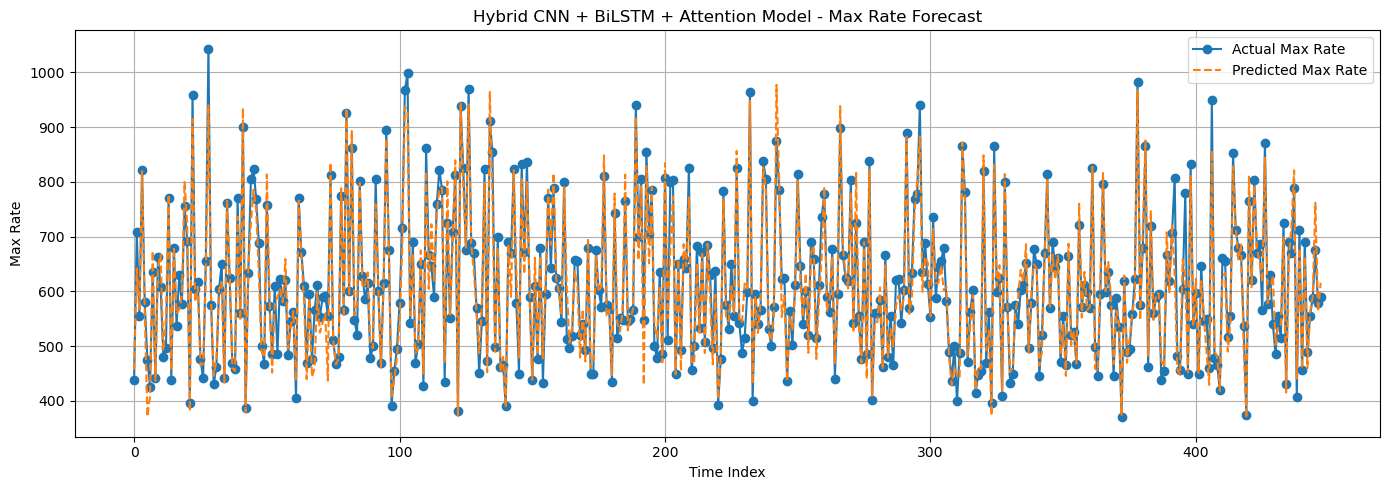

In [21]:
# === Best Version: Hybrid CNN + Bidirectional LSTM with Attention + MAPE ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Concatenate, 
                                     Conv1D, MaxPooling1D, Bidirectional, Layer)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

# === Attention Layer ===
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

# === Load & Preprocess Data ===
df = pd.read_csv('/Users/user/Downloads/final_cleaned_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Extract date parts
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df.drop(columns=['Date'], inplace=True)

# Define Features
target_col = 'Max Rate'
time_series_features = ['Quantity', 'Max Rate']
static_features = [col for col in df.columns if col not in [target_col] + time_series_features]

# Normalize
tscaler = MinMaxScaler()
sscaler = MinMaxScaler()
yscaler = MinMaxScaler()

df_seq_scaled = tscaler.fit_transform(df[time_series_features])
df_static_scaled = sscaler.fit_transform(df[static_features])
y_scaled = yscaler.fit_transform(df[[target_col]])

# Create Sequences
def create_sequences(data, static, target, time_steps=10):
    X_seq, X_static, y = [], [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i+time_steps])
        X_static.append(static[i+time_steps])
        y.append(target[i+time_steps])
    return np.array(X_seq), np.array(X_static), np.array(y)

X_seq, X_static, y = create_sequences(df_seq_scaled, df_static_scaled, y_scaled)

# Split
X_seq_train, X_seq_test, X_static_train, X_static_test, y_train, y_test = train_test_split(
    X_seq, X_static, y, test_size=0.2, random_state=42
)

# === Build Model ===
def build_model(seq_shape, static_shape):
    seq_input = Input(shape=seq_shape, name='seq_input')
    x = Conv1D(128, kernel_size=3, activation='relu')(seq_input)
    x = MaxPooling1D(pool_size=2)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Attention()(x)
    x = Dropout(0.3)(x)

    static_input = Input(shape=(static_shape,), name='static_input')
    y = Dense(64, activation='relu')(static_input)
    y = Dropout(0.3)(y)

    combined = Concatenate()([x, y])
    z = Dense(64, activation='relu')(combined)
    z = Dense(32, activation='relu')(z)
    output = Dense(1)(z)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(X_seq_train.shape[1:], X_static_train.shape[1])
model.summary()

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# === Train ===
history = model.fit(
    [X_seq_train, X_static_train], y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# === Evaluate ===
y_pred = model.predict([X_seq_test, X_static_test])
y_test_inv = yscaler.inverse_transform(y_test)
y_pred_inv = yscaler.inverse_transform(y_pred)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100
accuracy = 100 - mape

# === Print Metrics ===
print(f"\n📊 Test Metrics:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}, MAPE: {mape:.2f}%, Accuracy: {accuracy:.2f}%")

# === Plot Results ===
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv, label='Actual Max Rate', marker='o')
plt.plot(y_pred_inv, label='Predicted Max Rate', linestyle='--')
plt.title("Hybrid CNN + BiLSTM + Attention Model - Max Rate Forecast")
plt.xlabel("Time Index")
plt.ylabel("Max Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
